In [2]:
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from scipy.signal import medfilt
import os

In [3]:
SMOOTH_KERNEL = 101
IMAGE_HEIGHT = 0.3
IMAGE_OFFSET = 0.5
IMAGE_WIDTH_RATIO = 0.03
FIG_SIZE = (20, 6)

In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy.signal import medfilt

SMOOTH_KERNEL = 51
FIG_SIZE = (14, 5)
IMAGE_WIDTH_RATIO = 0.018
IMAGE_HEIGHT = 0.12

def plot_experiment(folder, title="", caption=None, max_iter=26000):
    # --- LOAD DATA ---
    with open(f"{folder}/loss_log.json") as f:
        data = json.load(f)
    iters = np.array(data["iterations"])
    loss = np.array(data["loss_D"])

    # --- CLIP TO MAX ITER ---
    mask = iters <= max_iter
    iters = iters[mask]
    loss = loss[mask]

    # smooth + negate
    loss = medfilt(-loss, SMOOTH_KERNEL)

    y_min = loss.min()
    y_max = loss.max()
    y_range = y_max - y_min

    # Row of images sits above the curve with a fixed gap
    IMG_TOP    = y_max + y_range * 0.55   # top edge of image row
    IMG_BOTTOM = y_max + y_range * 0.15   # bottom edge of image row (arrow tip ends here)
    img_height = IMG_TOP - IMG_BOTTOM

    # --- PLOT BASE CURVE ---
    fig, ax = plt.subplots(figsize=FIG_SIZE)
    ax.plot(iters, loss, color='blue', linewidth=1.5)

    # --- INTERVALS (2k → max_iter, every 2k) ---
    points = list(range(2000, max_iter + 1, 2000))
    x_total = iters[-1] - iters[0]
    img_half_width = x_total * IMAGE_WIDTH_RATIO * 3  # half-width of each thumbnail

    for p in points:
        img_path = f"{folder}/fake_samples_single_{p}.png"
        if not os.path.exists(img_path):
            continue

        # y value on the curve at this iteration
        idx = np.argmin(np.abs(iters - p))
        y_curve = loss[idx]

        # --- ARROW: from bottom of image row → curve point ---
        ax.annotate(
            "",
            xy=(p, y_curve),            # arrowhead lands on the curve
            xytext=(p, IMG_BOTTOM),     # tail starts at bottom of image row
            arrowprops=dict(
                arrowstyle="->,head_width=0.3,head_length=0.015",
                color="black",
                lw=0.8,
                shrinkA=0,   # no gap at tail
                shrinkB=2,   # tiny gap before touching the curve
            ),
        )

        # --- IMAGE: placed above the arrow tail ---
        img = mpimg.imread(img_path)
        ax.imshow(
            img,
            extent=(
                p - img_half_width,
                p + img_half_width,
                IMG_BOTTOM,             # bottom of image = arrow tail
                IMG_TOP,                # top of image
            ),
            aspect='auto',
            zorder=3,
        )

    # --- AXIS STYLE ---
    ax.set_xlabel("Generator iterations")
    ax.set_ylabel("Wasserstein estimate")
    ax.set_title(title)
    ax.set_xlim(0, max_iter)
    ax.set_ylim(y_min - y_range * 0.1, IMG_TOP + img_height * 0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # --- OPTIONAL CAPTION ---
    if caption:
        fig.text(0.5, -0.04, caption, ha="center", fontsize=11)

    plt.tight_layout()
    plt.show()

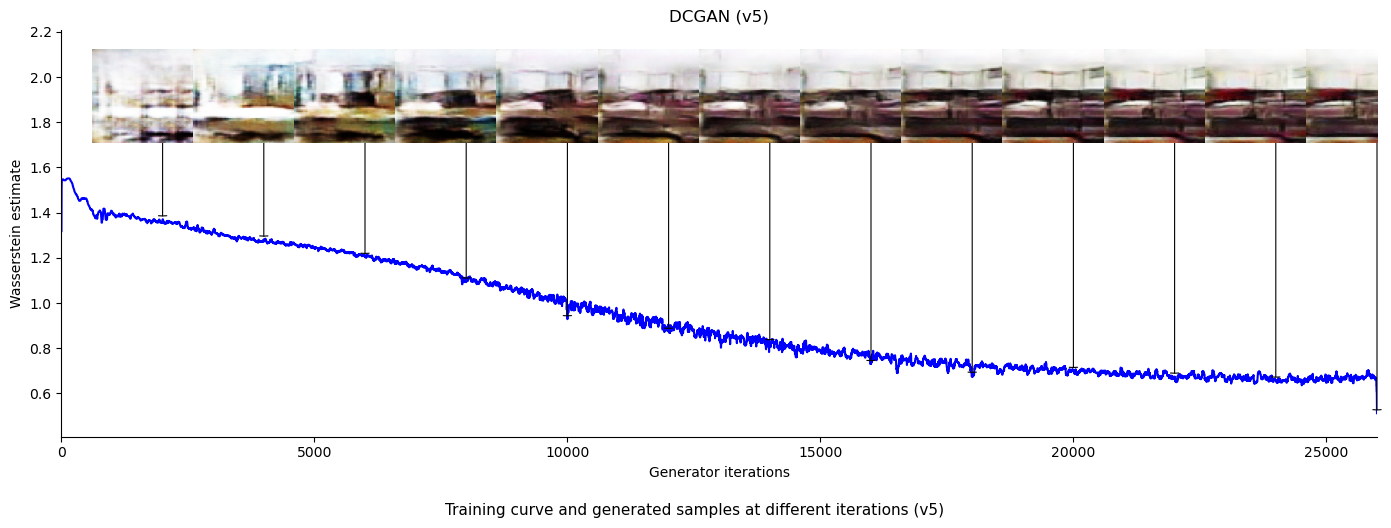

In [5]:
plot_experiment(
    folder="v5",
    title="DCGAN (v5)",
    caption="Training curve and generated samples at different iterations (v5)"
)

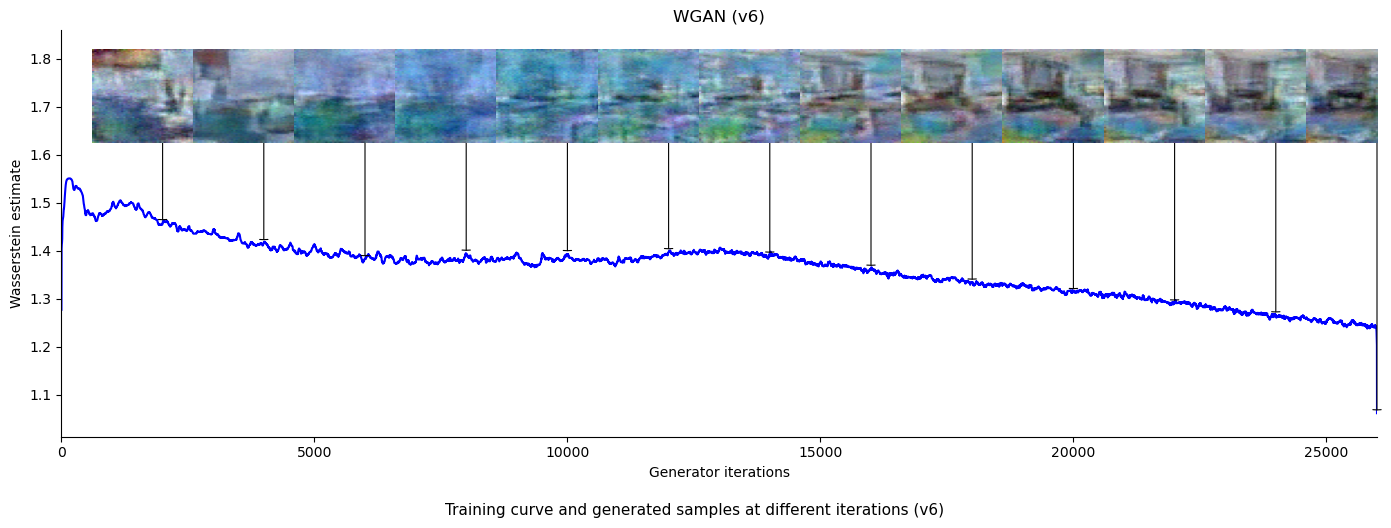

In [6]:
plot_experiment(
    folder="v6",
    title="WGAN (v6)",
    caption="Training curve and generated samples at different iterations (v6)"
)

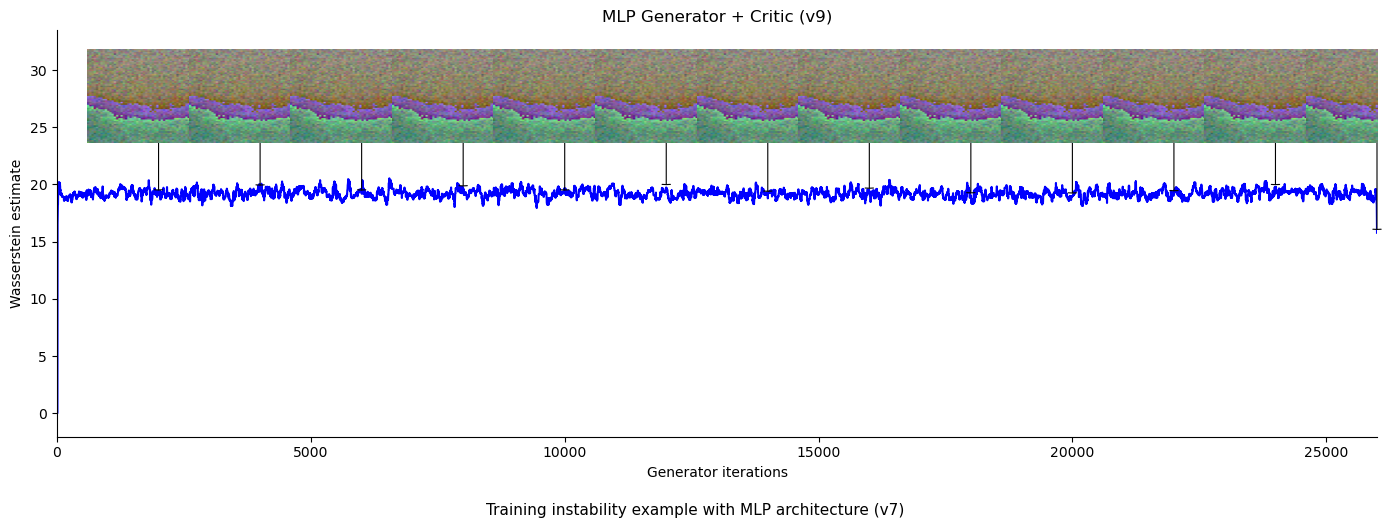

In [7]:
plot_experiment(
    folder="v9",
    title="MLP Generator + Critic (v9)",
    caption="Training instability example with MLP architecture (v7)"
)